In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the data
df = pd.read_csv("data/tv-shows.csv")
print(f"Dataset Shape: {df.shape}")
df.head(3)

Dataset Shape: (9338, 13)


,id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform
0,1,Movie,ChuChuTV Surprise Eggs Learning Videos (English),NaN,NaN,NaN,"October 18, 2019",2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix
1,2,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,"November 7, 2017",2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix
2,3,TV Show,Champions,NaN,"Anders Holm, Fortune Feimster, Andy Favreau, J...",United States,"June 19, 2021",2018,TV-14,1 Season,TV Comedies,"Years after getting his girlfriend pregnant, w...",Netflix


In [20]:
print("--- Missing Values Count ---")
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
print(missing_data)

print("\n--- Missing Values Percentage ---")
missing_percentage = (missing_data / len(df)) * 100
print(missing_percentage)

--- Missing Values Count ---
director      2855
country        962
cast           938
date_added      13
rating           7
duration         3
dtype: int64

--- Missing Values Percentage ---
director      30.573999
country       10.301992
cast          10.044978
date_added     0.139216
rating         0.074963
duration       0.032127
dtype: float64


C:\Users\amanc\AppData\Local\Temp\ipykernel_16068\124707148.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='grouped_genre', data=df, order=df['grouped_genre'].value_counts().index, palette="viridis")


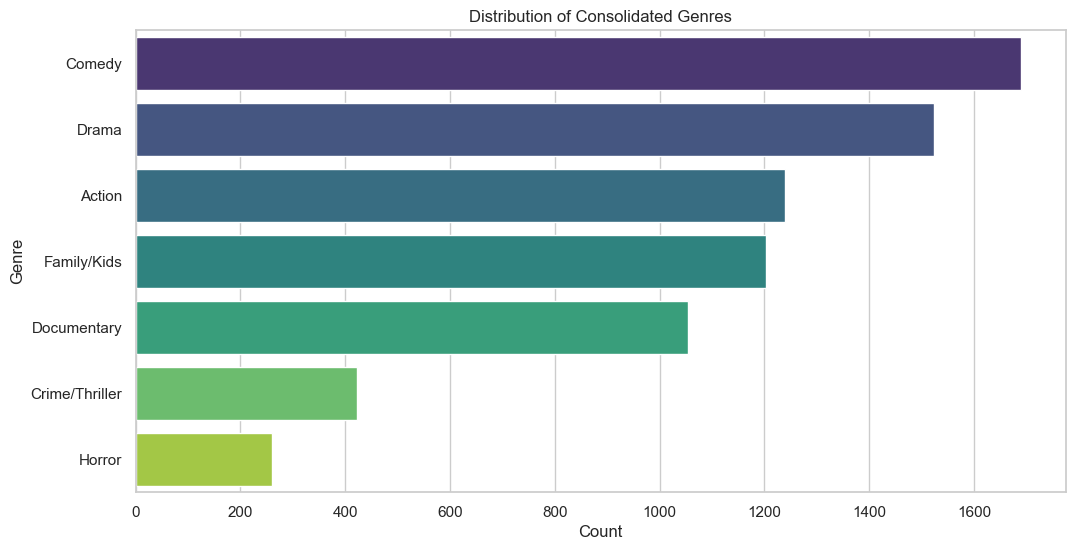

In [21]:
# Apply the exact same grouping logic we used in the pipeline
df = df.dropna(subset=['listed_in'])
df['primary_genre'] = df['listed_in'].apply(lambda x: str(x).split(',')[0].strip())

genre_mapping = {
    'Dramas': 'Drama', 'Drama': 'Drama', 'TV Dramas': 'Drama', 
    'Comedies': 'Comedy', 'Comedy': 'Comedy', 'TV Comedies': 'Comedy', 'Stand-Up Comedy': 'Comedy',
    'Action & Adventure': 'Action', 'Action-Adventure': 'Action', 'TV Action & Adventure': 'Action',
    'Documentaries': 'Documentary', 'Documentary': 'Documentary', 'Docuseries': 'Documentary',
    'Children & Family Movies': 'Family/Kids', "Kids' TV": 'Family/Kids', 'Family': 'Family/Kids', 'Animation': 'Family/Kids',
    'Crime TV Shows': 'Crime/Thriller', 'Thrillers': 'Crime/Thriller', 'TV Thrillers': 'Crime/Thriller', 'Crime': 'Crime/Thriller',
    'Horror Movies': 'Horror', 'TV Horror': 'Horror'
}
df['grouped_genre'] = df['primary_genre'].map(genre_mapping)

plt.figure(figsize=(12, 6))
sns.countplot(y='grouped_genre', data=df, order=df['grouped_genre'].value_counts().index, palette="viridis")
plt.title("Distribution of Consolidated Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

--- Text Feature Word Count Statistics ---
count    9338.000000
mean       25.382523
std         5.080498
min         6.000000
25%        23.000000
50%        26.000000
75%        29.000000
max        51.000000
Name: text_word_count, dtype: float64


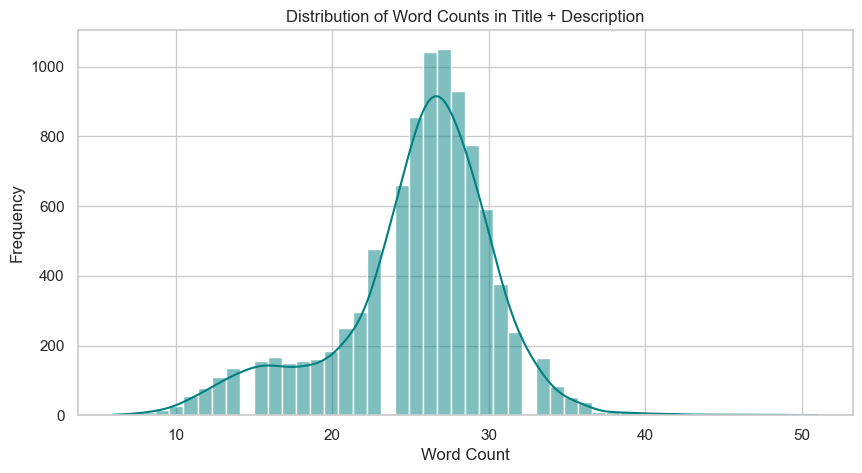

In [22]:
# Create the text feature
df['text_feature'] = df['title'].fillna('') + " " + df['description'].fillna('')

# Calculate word counts
df['text_word_count'] = df['text_feature'].apply(lambda x: len(str(x).split()))

print("--- Text Feature Word Count Statistics ---")
print(df['text_word_count'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['text_word_count'], bins=50, kde=True, color='teal')
plt.title("Distribution of Word Counts in Title + Description")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

C:\Users\amanc\AppData\Local\Temp\ipykernel_16068\779087591.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movies_df, x='duration_num', y='grouped_genre', palette='Set2', ax=axes[1])


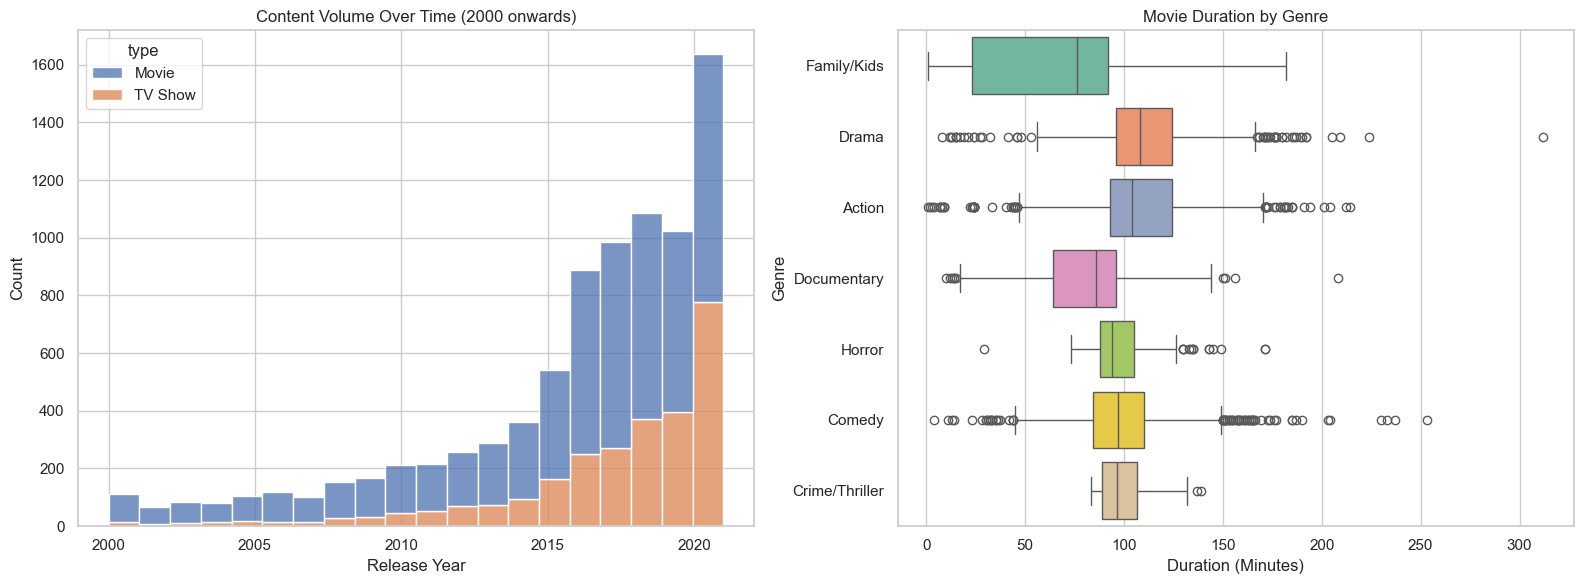

In [23]:
# Clean duration
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float).fillna(0)

# Filter for recent years for better visualization
recent_df = df[df['release_year'] >= 2000]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Release Year by Type
sns.histplot(data=recent_df, x='release_year', hue='type', multiple='stack', bins=20, ax=axes[0])
axes[0].set_title("Content Volume Over Time (2000 onwards)")
axes[0].set_xlabel("Release Year")

# Plot 2: Boxplot of Duration (Movies only, to avoid comparing seasons to minutes)
movies_df = df[df['type'] == 'Movie']
sns.boxplot(data=movies_df, x='duration_num', y='grouped_genre', palette='Set2', ax=axes[1])
axes[1].set_title("Movie Duration by Genre")
axes[1].set_xlabel("Duration (Minutes)")
axes[1].set_ylabel("Genre")

plt.tight_layout()
plt.show()